# 强化学习-多臂赌博机

代码为reinforcement-learning-an-introduction的学习笔记

参考官方书配套代码：https://github.com/ShangtongZhang/reinforcement-learning-an-introduction

埃及猪肉

```
#######################################################################
# Copyright (C)                                                       #
# 2016-2018 Shangtong Zhang(zhangshangtong.cpp@gmail.com)             #
# 2016 Tian Jun(tianjun.cpp@gmail.com)                                #
# 2016 Artem Oboturov(oboturov@gmail.com)                             #
# 2016 Kenta Shimada(hyperkentakun@gmail.com)                         #
# Permission given to modify the code as long as you keep this        #
# declaration at the top                                              #
#######################################################################
```

In [46]:
# 预先准备部分

# 导入第三方库
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from tqdm import trange
import random

# 解决matplotlib中文显示问题
# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']  # Windows 用 SimHei
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

# 添加随机数种子
random.seed(3)      # Python 内置 random 模块的种子
np.random.seed(3)   # NumPy 随机数种子


# 一、测试平台

将进行2000次试验，每次实验存在$k$个摇臂，每次试验摇臂的价值都不同，每次试验都会重新生成$k$个价值

其中一次试验生成的真实价值为$q_*(a)，a=1,2,3...,k$

生成的价值服从正态分布，均值为0，方差为1

参数如下：
- `k_arm`为k臂赌博机的臂数量



第 1 摇臂的真实值/期望为: 1.7886284734303186
第 2 摇臂的真实值/期望为: 0.43650985051198943
第 3 摇臂的真实值/期望为: 0.09649746807200862
第 4 摇臂的真实值/期望为: -1.8634927033644908
第 5 摇臂的真实值/期望为: -0.27738820251439905
第 6 摇臂的真实值/期望为: -0.35475897926898675
第 7 摇臂的真实值/期望为: -0.08274148148245977
第 8 摇臂的真实值/期望为: -0.6270006768238473
第 9 摇臂的真实值/期望为: -0.04381816897592824
第 10 摇臂的真实值/期望为: -0.47721803035950267


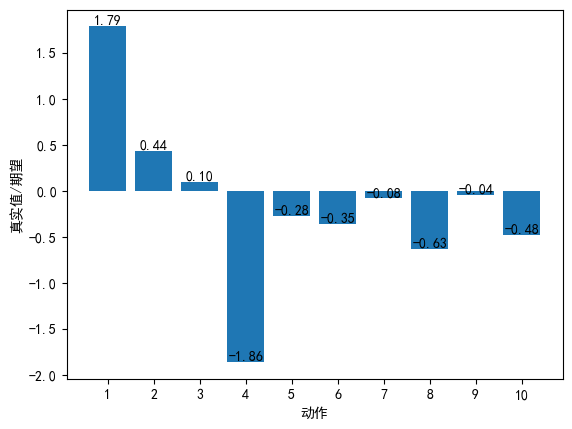

In [47]:
k_arm = 10



# 真实值q*(a)服从正态分布，均值为0，方差为1
q_true = np.random.randn(k_arm)

# 绘制真实值的柱状图
for i in range(k_arm):
    print(f"第 {i+1} 摇臂的真实值/期望为: {q_true[i]}")
    
# bar的x位置从0到9改为1到10
bars = plt.bar(range(1, k_arm + 1), q_true)

# 文本位置从0到9改为1到10
for bar, val in zip(bars, q_true):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{val:.2f}',
             ha='center', va='bottom',
             fontsize=10)

# x轴刻度设置为1到10
plt.xticks(range(1, k_arm + 1))

plt.xlabel("动作")
plt.ylabel("真实值/期望")
plt.show()


在每一轮试验中，实际收益并不会完全等于动作价值$q_*(a)$

实际的收益$R_t$呈现一定分布，假定其由一个均值为$q_*(a)$，方差为$1$的正态分布决定

所以单轮次试验中的实际的收益$R_t$如图所示，为阴影区域中的一点。


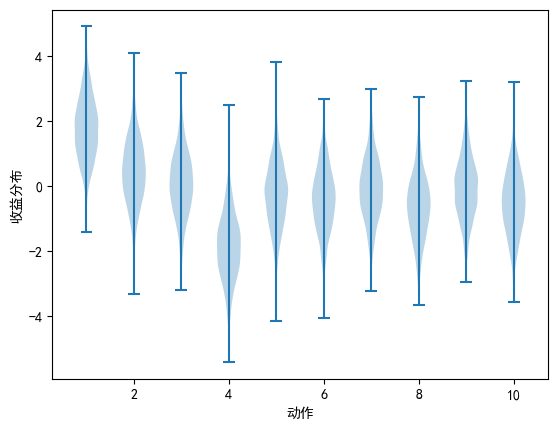

In [48]:

# 实际收益是真实值加上一个服从正态分布的噪声组成的
dataset = np.random.randn(2000, k_arm) + q_true

plt.violinplot(dataset)
plt.xlabel("动作")
plt.ylabel("收益分布")
plt.show()


# 贪心算法对比


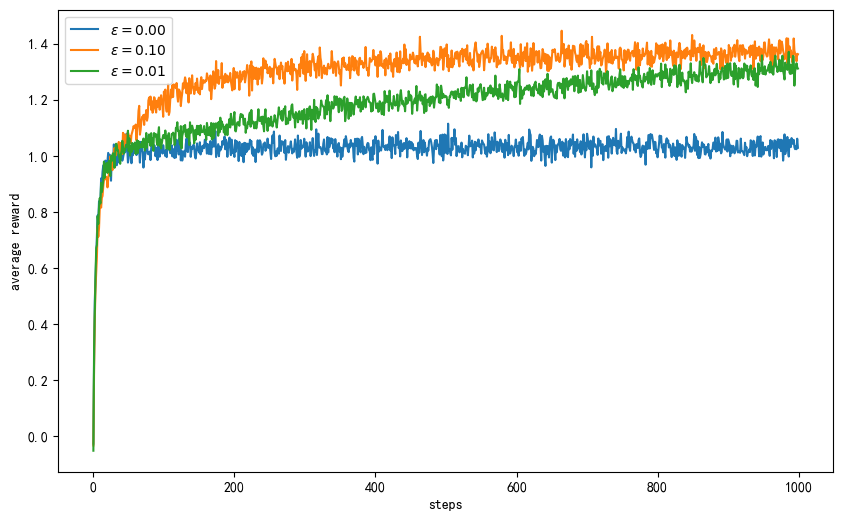

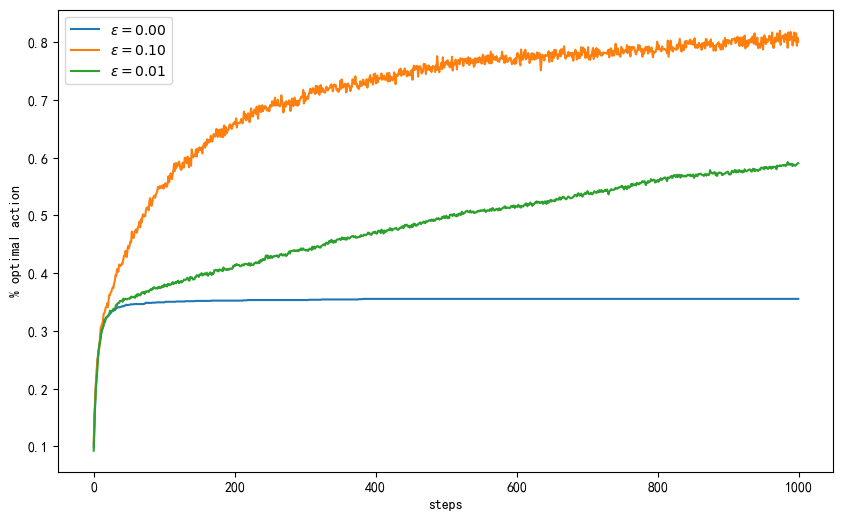

In [49]:

# 模拟参数
runs = 2000
time = 1000

# 三种 epsilon 配置
epsilons = [0, 0.1, 0.01]
k_arm = 10

# 初始化存储结果的数组
rewards = np.zeros((len(epsilons), runs, time))
best_action_counts = np.zeros((len(epsilons), runs, time))

# 遍历每种 epsilon 配置
for i in range(len(epsilons)):
    eps = epsilons[i]
    
    # 遍历每次运行
    for r in range(runs):
        # === reset_bandit 逻辑开始 ===
        # 初始化真实的 Q 值
        q_true = np.random.randn(k_arm) + 0.

        # 初始化估计的 Q 值
        q_estimation = np.zeros(k_arm) + 0.
        # 初始化动作计数
        action_count = np.zeros(k_arm)
        # 最优动作
        best_action = np.argmax(q_true)
        # 时间步
        t = 0
        # 平均奖励
        average_reward = 0
        # === reset_bandit 逻辑结束 ===
        
        # 遍历每个时间步
        for step_idx in range(time):
            # === act 逻辑开始 (epsilon-greedy) ===
            if np.random.rand() < eps:
                action = np.random.choice(np.arange(k_arm))
            else:
                q_best = np.max(q_estimation)
                action = np.random.choice(np.where(q_estimation == q_best)[0])
            # === act 逻辑结束 ===
            
            # === step 逻辑开始 ===
            # 生成奖励
            reward = np.random.randn() + q_true[action]
            t += 1
            action_count[action] += 1
            average_reward += (reward - average_reward) / t
            
            # 使用样本平均更新
            q_estimation[action] += (reward - q_estimation[action]) / action_count[action]
            # === step 逻辑结束 ===
            
            # 存储结果
            rewards[i, r, step_idx] = reward
            if action == best_action:
                best_action_counts[i, r, step_idx] = 1

# 计算平均值
mean_best_action_counts = best_action_counts.mean(axis=1)
mean_rewards = rewards.mean(axis=1)

# 绘制平均奖励图
plt.figure(figsize=(10, 6))
for i in range(len(epsilons)):
    plt.plot(mean_rewards[i], label='$\epsilon = %.02f$' % (epsilons[i]))
plt.xlabel('steps')
plt.ylabel('average reward')
plt.legend()
plt.show()

# 绘制最优动作比例图
plt.figure(figsize=(10, 6))
for i in range(len(epsilons)):
    plt.plot(mean_best_action_counts[i], label='$\epsilon = %.02f$' % (epsilons[i]))
plt.xlabel('steps')
plt.ylabel('% optimal action')
plt.legend()
plt.show()
